   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

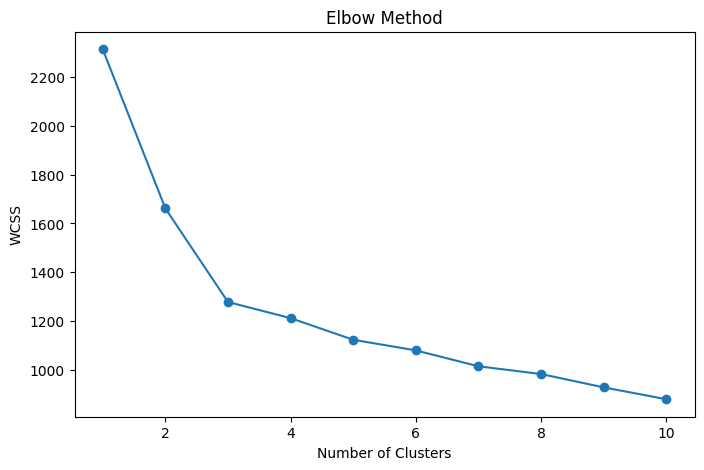

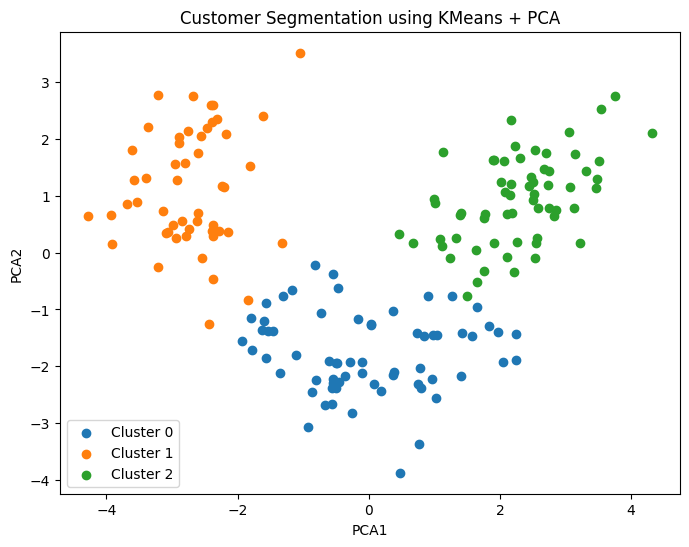


Clustering Completed Successfully!


In [1]:
# Customer Segmentation using KMeans + PCA

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine

# Load Dataset
data = load_wine()

df = pd.DataFrame(data.data, columns=data.feature_names)

print(df.head())

# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Train KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# PCA for Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Create PCA DataFrame
pca_df = pd.DataFrame(data=pca_data, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters

# Plot Clusters
plt.figure(figsize=(8,6))

for cluster in np.unique(clusters):
    plt.scatter(
        pca_df[pca_df['Cluster'] == cluster]['PCA1'],
        pca_df[pca_df['Cluster'] == cluster]['PCA2'],
        label=f'Cluster {cluster}'
    )

plt.title("Customer Segmentation using KMeans + PCA")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.show()

print("\nClustering Completed Successfully!")